<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/ESAA_jooyoung_YB_0504_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#05_01 회귀 소개
회귀(regression)는 독립변수와 종속변수의 관계를 분석해 값을 예측하는 통계·머신러닝 기법이다.

갈톤의 키 연구에서 유래했으며, 극단적인 값도 시간이 지나면 평균에 가까워지는 “평균으로의 회귀” 개념을 바탕으로 한다.

예를 들어 방 개수, 방 크기, 주변 학교 같은 변수로 아파트 가격을 예측할 수 있다.

회귀식은 Y = W₁X₁ + W₂X₂ + … + WₙXₙ처럼 나타내며, W는 각 변수의 영향력을 의미하는 회귀 계수이다.

회귀는 선형/비선형 회귀, 단일/다중 회귀로 나눌 수 있다.

- 일반 선형 회귀: 예측값과 실제 값의 RSS(Residual Sum of Squares)를 최소화할 수 있도록 회귀 계수를 최적화하며, 규제(Regularization)를 적용하지 않은 모델.
- 릿지(Ridge)： 선형 회귀에 L2 규제를 추가한 회귀 모델.L2 규제
는 상대적으로 큰 회귀 계수 값의 예측 영향도를 감소시키기 위해서 회귀 계수값을 더 작게 만드는 규제 모델.
- 라쏘(Lasso)： 선형 회귀에 L1 규제를 적용한 방식.
L1 규제는 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않게 하는 것.
- 엘라스틱넷(티asticNet)： L2, L1 규제를 함께 결합한 모델입니다. L1 규제로
피처의 개수를 줄임과 동시에 L2 규제로 계수 값의 크기를 조정.
- 로지스틱 회귀(Logistic Regression)：  매우 강력한 분류 알고리즘. 일반적으로 이진 분류뿐만 아니라 희소 영역의 분류에서 뛰어난 예측 성능을 보입니다.

#05_02 단순 선형 회귀를 통한 회귀 이해
단순 선형 회귀는 독립변수 1개와 종속변수 1개의 관계를 직선 형태로 나타내는 회귀이다.  
예를 들어 주택 크기(X)에 따라 주택 가격(Y)을 예측하는 경우, 주택 크기가 커질수록 가격도 높아지는 경향이 있으므로 이를 직선으로 모델링할 수 있다.
회귀식은 다음과 같다.  
`ŷ = w₀ + w₁x`  
여기서 ŷ는 예측값, x는 독립변수, w₀는 절편, w₁은 기울기이다.  
즉, 단순 선형 회귀에서는 가장 적절한 절편과 기울기를 찾는 것이 핵심이다.  
실제값과 예측값의 차이를 오차 또는 잔차라고 한다.  
오차는 양수와 음수가 될 수 있기 때문에 단순히 더하면 서로 상쇄될 수 있다.   그래서 오차의 절댓값을 더하는 MAE나, 오차를 제곱해서 더하는 RSS 방식을 사용한다.  
RSS는 잔차 제곱합으로, 모든 데이터에 대해 실제값과 예측값의 차이를 제곱해 더한 값이다.  
`RSS = 1/N Σ(yi - (w₀ + w₁xi))²`  
회귀 모델의 목표는 이 RSS, 즉 비용 함수 또는 손실 함수를 최소로 만드는 w₀와 w₁을 학습하는 것이다.  
따라서 머신러닝 기반 회귀의 핵심은 데이터를 학습하면서 오차가 가장 작아지는 최적의 회귀 계수를 찾는 것이다.  

#05_03 비용 최소화하기 - 경사 하강법（Gradient Descent） 소개


경사 하강법은 비용 함수가 최소가 되는 회귀 계수 w를 찾는 방법이다.  
회귀에서는 오차를 줄이는 것이 목표이므로, 비용 함수인 RSS가 가장 작아지는 w₀, w₁ 값을 찾아야 한다.  

w 파라미터가 적으면 직접 계산할 수도 있지만, 파라미터가 많아지면 고차원 방정식으로 풀기 어렵다. 그래서 경사 하강법을 사용한다.  

경사 하강법은 이름 그대로 “점진적으로 내려가는 방법”이다. 산에서 가장 낮은 지점을 찾듯이, 현재 위치에서 비용 함수가 작아지는 방향으로 w 값을 조금씩 업데이트한다.  

핵심 원리는 비용 함수를 미분하여 기울기를 구하고, 그 기울기가 작아지는 방향으로 이동하는 것이다.  
비용 함수가 더 이상 줄어들지 않는 지점에 도달하면 그때의 w 값을 최적의 회귀 계수로 본다.  

단순 선형 회귀의 비용 함수는 다음과 같다.  

`R(w) = 1/N Σ(yi - (w₀ + w₁xi))²`  

여기서 yi는 실제값, w₀ + w₁xi는 예측값이다.

경사 하강법의 기본 과정은 다음과 같다.
1. w₀, w₁을 임의의 값으로 설정한다.
2. 현재 w₀, w₁으로 비용 함수 값을 계산한다.
3. 비용 함수의 기울기를 구한다.
4. 오차가 줄어드는 방향으로 w₀, w₁을 업데이트한다.
5. 비용 함수가 더 이상 줄어들지 않을 때까지 반복한다.

이때 한 번에 얼마나 이동할지 정하는 값을 학습률이라고 한다.
학습률이 너무 크면 최솟값을 지나칠 수 있고, 너무 작으면 학습 속도가 느려질 수 있다.

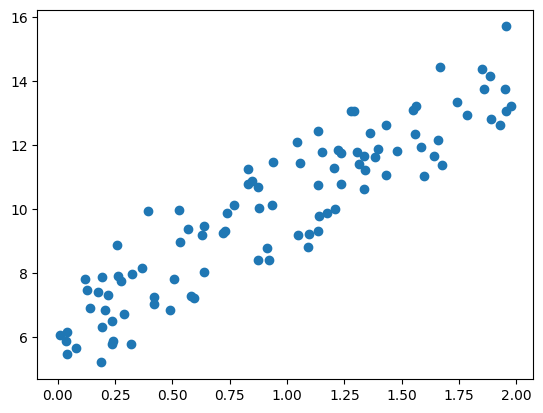

In [1]:
import numpy as np
import matplotlib.pyplot as pit
%matplotlib inline
np.random.seed(0)
# y = 4X + 6을 근사(w1=4, w0=6). 임의의 값은 노이즈를 위해 만듦.
X = 2 * np.random.rand(100,1)
y = 6 +4 * X+np.random.randn(100,1)
# X, y 데이터 세트 산점도로 시각화
pit.scatter(X, y)

In [6]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

In [7]:
#경사 하강법을 gradient_descentO라는 함수를 생성해 구현
# w1과 w0를 업데이트할 w1_update, w0_update를 반환.
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)

    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)

    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y - y_pred

    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N, 1))

    # w1과 w0를 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2 / N) * learning_rate * (np.dot(X.T, diff))
    w0_update = -(2 / N) * learning_rate * (np.dot(w0_factors.T, diff))

    return w1_update, w0_update

In [8]:
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0을 업데이트 적용함.
def gradient_descent_steps(X, y, iters=10000):
    # w0와 w1을 모두 0으로 초기화.
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출해 w1, w0 업데이트 수행.
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [9]:
def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0, 0], w0[0, 0]))

y_pred = w1[0, 0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


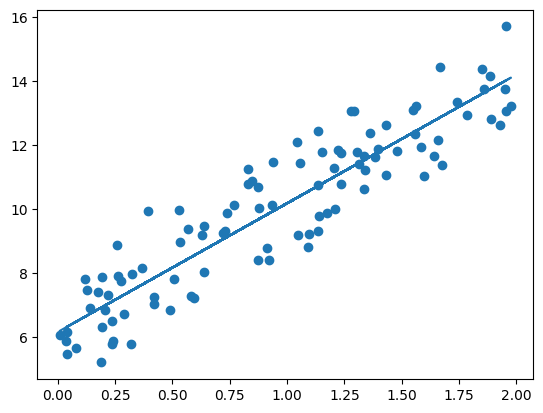

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, y_pred)

일반 경사 하강법: 전체 데이터를 사용해 업데이트  
확률적 경사 하강법: 일부 데이터를 사용해 업데이트 → 더 빠름

In [13]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1, 1))
    w1 = np.zeros((1, 1))

    for ind in range(iters):
        np.random.seed(ind)

        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]

        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update

    return w1, w0

In [14]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:", round(w1[0, 0], 3), "w0:", round(w0[0, 0], 3))

y_pred = w1[0, 0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


피처가 여러 개일 때의 회귀식은 다음과 같다.  
`ŷ = w0 + w1X1 + w2X2 + ... + wmXm`
여기서 X1, X2, ..., Xm은 여러 개의 피처이고, w1, w2, ..., wm은 각 피처에 대한 회귀 계수이다.  
피처가 M개라면 회귀 계수는 절편 w0까지 포함해 총 M+1개가 된다.  
여러 데이터와 여러 피처가 있을 때는 행렬 연산을 이용해 예측값을 한 번에 계산할 수 있다.  
`ŷ = np.dot(Xmat, W.T) + w0`  
또는 절편 w0를 가중치 배열 W 안에 포함시키기 위해, Xmat의 첫 번째 열에 값이 모두 1인 피처를 추가할 수 있다.  
이렇게 하면 식을 더 간단하게 표현할 수 있다.  
`ŷ = Xmat * W.T`  
즉, 다중 선형 회귀는 여러 피처를 이용해 예측값을 계산하며, 행렬 연산을 사용하면 많은 데이터의 예측값을 효율적으로 구할 수 있다.

#05_04 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측
###LinearRegression 클래스 一 Ordinary Least Squares

In [20]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=1)

LinearRegression은 사이킷런에서 제공하는 선형 회귀 모델이다.

`fit_intercept=True`  
절편을 계산할지 정하는 옵션이다. False이면 절편을 사용하지 않고 0으로 둔다.

`coef_`  
학습 후 구해진 회귀 계수이다.

`intercept_`  
학습 후 구해진 절편 값이다.

OLS 기반 선형 회귀는 피처 간 상관관계가 높으면 오류에 민감해질 수 있다.  
이 문제를 다중공선성이라고 하며, 해결 방법으로는 중요한 피처만 남기거나, 규제를 적용하거나, PCA로 차원을 축소하는 방법이 있다.  
회귀 평가는 실제값과 예측값의 차이를 기준으로 한다.  
오차가 양수와 음수로 상쇄될 수 있으므로 절댓값, 제곱값, 제곱근 등을 이용한다.  
주요 회귀 평가 지표는 다음과 같다.  

`MAE`: 오차 절댓값의 평균  
`MSE`: 오차 제곱의 평균  
`RMSE`: MSE에 루트를 씌운 값  
`R²`: 실제값의 분산 대비 예측값의 분산 비율로, 1에 가까울수록 예측 성능이 좋다  
`MSLE`, `RMSLE`: 오차에 로그를 적용한 지표  

사이킷런의 cross_val_score, GridSearchCV에서 회귀 평가 지표를 사용할 때는 보통 neg_mean_absolute_error처럼 앞에 neg_가 붙는다.
이는 사이킷런이 점수가 클수록 좋은 모델로 평가하기 때문에, 원래 작을수록 좋은 오차 지표에 음수를 붙여 사용하기 때문이다.

보스턴 주택 가격 데이터는 LinearRegression 예제로 많이 사용되며, 여러 지역 특성 피처를 이용해 주택 가격 중앙값 MEDV를 예측하는 데이터이다.

In [22]:
import pandas as pd

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
bostonDF = pd.DataFrame(data, columns=feature_names)
bostonDF['PRICE'] = target

print('Boston 데이터 세트 크기 :', bostonDF.shape)
display(bostonDF.head())

Boston 데이터 세트 크기 : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

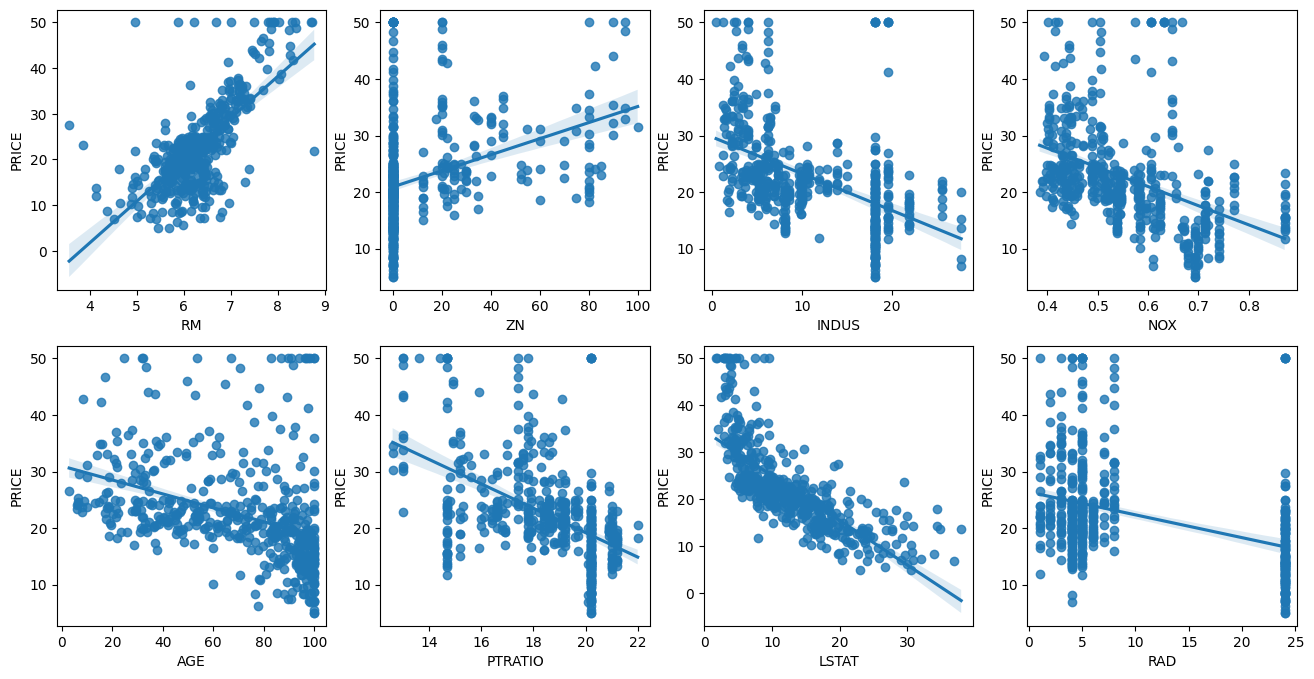

In [25]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16, 8), ncols=4, nrows=2)

lm_features = ['RM', 'ZN', 'INDUS', 'NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i / 4)
    col = i % 4

    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_target, test_size=0.3, random_state=156
)

# 선형 회귀 OLS로 학습/예측/평가 수행.
lr = LinearRegression()
lr.fit(X_train, y_train)

y_preds = lr.predict(X_test)

mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f}, RMSE : {1:.3f}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 17.297, RMSE : 4.159
Variance score : 0.757


In [27]:
print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: 40.995595172164826
회귀 계수값: [ -0.1   0.1   0.    3.  -19.8   3.4   0.   -1.7   0.4  -0.   -0.9   0.
  -0.6]


In [28]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. 인덱스 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns)
coeff.sort_values(ascending=False)

,0
RM,3.4
CHAS,3.0
RAD,0.4
ZN,0.1
INDUS,0.0
B,0.0
TAX,-0.0
AGE,0.0
CRIM,-0.1
LSTAT,-0.6


In [30]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

lr = LinearRegression()

# cross_val_score()로 5 폴드 세트로 MSE를 구한 뒤 이를 기반으로 다시 RMSE 구함.
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores:  [-12.46 -26.05 -33.07 -80.76 -33.31]
 5 folds 의 개별 RMSE scores :  [3.53 5.1  5.75 8.99 5.77]
 5 folds 의 평균 RMSE : 5.829 


#05_05 다항 회귀와 과(대)적합/과소적합 이해
**다항 회귀이해**  
기존 선형 회귀는 독립변수와 종속변수의 관계를 직선 형태로 표현한다.

`y = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ`

하지만 실제 데이터의 관계가 항상 직선으로만 나타나는 것은 아니다.  
이때 독립변수를 제곱하거나 서로 곱한 항을 추가해 곡선 형태로 표현하는 방법이 다항 회귀이다.

예를 들어 다음과 같이 표현할 수 있다.

`y = w₀ + w₁x₁ + w₂x₂ + w₃x₁x₂ + w₄x₁² + w₅x₂²`

다항 회귀는 곡선 형태를 만들기 때문에 비선형 회귀처럼 보이지만, 회귀 계수 w에 대해서는 여전히 선형이므로 선형 회귀에 속한다.

즉, 선형/비선형 회귀를 나누는 기준은 독립변수의 모양이 아니라 회귀 계수가 선형인지 여부이다.

사이킷런은 다항 회귀 모델을 따로 제공하지 않는다.
대신 PolynomialFeatures를 사용해 기존 피처를 다항식 피처로 변환한 뒤, 선형 회귀 모델에 적용한다.

예를 들어 [x₁, x₂]를 2차 다항식으로 변환하면 다음과 같은 피처가 만들어진다.

[1, x₁, x₂, x₁², x₁x₂, x₂²]

정리하면, 다항 회귀는 기존 피처를 제곱항·교차항 등으로 확장해서 곡선 형태의 관계를 선형 회귀 모델로 학습하는 방법이다.

In [31]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0, 1], [2, 3]]의 2x2 행렬 생성
X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 피처:\n', X)

# degree = 2인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용해 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)

print('변환된 2차 다항식 계수 피처:\n', poly_ftr)

일차 단항식 계수 피처:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 피처:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [32]:
# 3차 다항 계수를 이용해 3차 다항 회귀 함수식을 PolynomialFeatures와 LinearRegression 클래스를 이용해 유도
def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0] ** 2 + 4 * X[:, 1] ** 3
    return y

X = np.arange(4).reshape(2, 2)
print('일차 단항식 계수 feature:\n', X)

y = polynomial_func(X)
print('삼차 다항식 결정값:\n', y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
삼차 다항식 결정값:
 [  5 125]


In [33]:
# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature:\n', poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr, y)

print('Polynomial 회귀 계수\n', np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature:
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2 * X[:, 0] + 3 * X[:, 0] ** 2 + 4 * X[:, 1] ** 3
    return y

# Pipeline 객체로 Streamline하게 Polynomial Feature 변환과 Linear Regression을 연결
model = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('linear', LinearRegression())
])

X = np.arange(4).reshape(2, 2)
y = polynomial_func(X)

model = model.fit(X, y)

print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


**다항 회귀를 이용한 과소적합 및 과적합 이해**  
다항 회귀는 피처와 타깃이 직선 관계가 아닐 때, 복잡한 곡선 관계를 모델링할 수 있는 방법이다.

다항식의 차수 degree가 높아질수록 더 복잡한 피처 관계를 표현할 수 있다.
하지만 차수가 너무 높아지면 학습 데이터에만 지나치게 잘 맞는 문제가 생긴다.

이 현상을 과적합이라고 한다.

즉, 학습 데이터에서는 예측 성능이 좋아 보이지만, 새로운 테스트 데이터에서는 오히려 예측 정확도가 떨어질 수 있다.

사이킷런 예제에서는 다항 회귀의 차수를 바꿔가며 과소적합과 과적합을 비교한다.
데이터는 코사인 함수 형태에 잡음이 추가된 형태로 만들어지고, 다양한 차수의 다항 회귀 모델을 적용해 예측 곡선과 정확도를 비교한다.

정리하면, 다항 회귀는 복잡한 관계를 표현할 수 있지만, 차수가 너무 높으면 과적합이 발생하므로 적절한 차수를 선택하는 것이 중요하다.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.4077289625098685 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987232064 입니다.

Degree 15 회귀 계수는 [-2.98293000e+03  1.03899390e+05 -1.87416123e+06  2.03716219e+07
 -1.44873283e+08  7.09315363e+08 -2.47065792e+09  6.24561050e+09
 -1.15676510e+10  1.56894936e+10 -1.54006023e+10  1.06457264e+10
 -4.91377530e+09  1.35919645e+09 -1.70380786e+08] 입니다.
Degree 15 MSE 는 181238256.56423894 입니다.


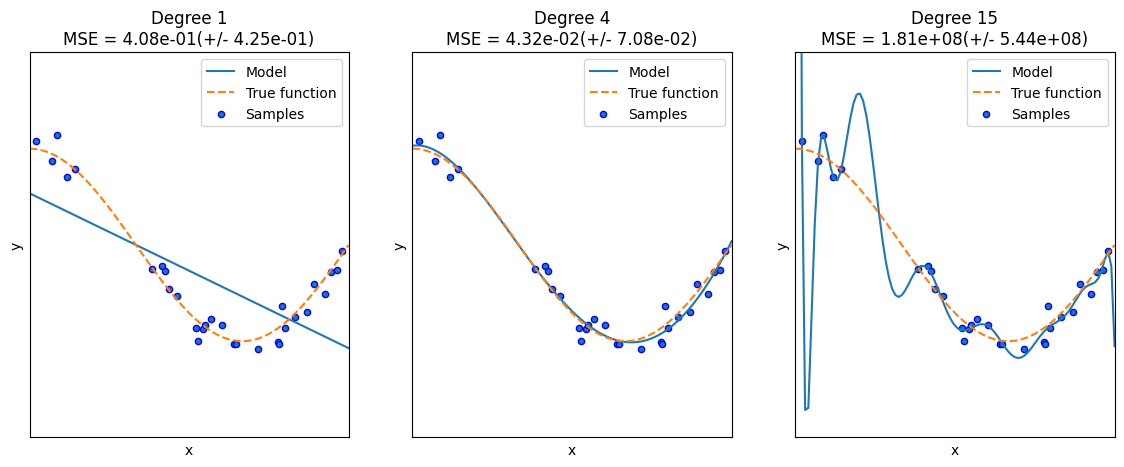

In [36]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])

    pipeline.fit(X.reshape(-1, 1), y)

    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(
        pipeline,
        X.reshape(-1, 1),
        y,
        scoring="neg_mean_squared_error",
        cv=10
    )

    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_

    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1 * np.mean(scores)))

    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)

    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")

    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()
    ))

plt.show()

다항 회귀에서 차수 degree를 다르게 설정하면 모델의 복잡도가 달라진다.

Degree 1은 단순 직선 모델이다.
너무 단순해서 실제 코사인 형태의 데이터 패턴을 잘 반영하지 못한다.
따라서 과소적합 모델에 해당한다.

Degree 4는 실제 데이터의 곡선 패턴을 비교적 잘 반영한다.
학습 데이터에 지나치게 맞추지도 않고, 너무 단순하지도 않아서 가장 균형 잡힌 모델이다.

Degree 15는 학습 데이터의 작은 잡음까지 지나치게 반영한다.
학습 데이터에는 잘 맞지만 새로운 데이터에 대한 예측 성능은 떨어지는 과적합 모델이다.
회귀 계수도 매우 큰 값이 되어 불안정한 모델이 된다.

좋은 모델은 너무 단순하지도, 너무 복잡하지도 않은 균형 잡힌 모델이다.

**편향-분산 트레이드오프**

편향은 모델이 실제 패턴을 얼마나 단순하게 가정하는지를 의미한다.
편향이 높으면 모델이 너무 단순해서 과소적합이 발생하기 쉽다.

분산은 모델이 학습 데이터의 변화에 얼마나 민감하게 반응하는지를 의미한다.
분산이 높으면 학습 데이터의 작은 변화나 잡음까지 반영해서 과적합이 발생하기 쉽다.

일반적으로 모델 복잡도가 낮으면 편향은 높고 분산은 낮다.
반대로 모델 복잡도가 높으면 편향은 낮고 분산은 높다.

따라서 예측 성능이 좋은 모델을 만들려면 편향과 분산 사이의 균형을 맞춰야 한다.
이 균형을 찾는 과정이 편향-분산 트레이드오프이다.

- 과소적합:	높은 편향, 낮은 분산
- 적절한 모델:	중간 편향, 중간 분산
- 과적합: 낮은 편향, 높은 분산